<a href="https://colab.research.google.com/github/atina-21/PengolahanCitra/blob/main/jobsheet4_PengolahanCitra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JOBSHEET 04: SEGMENTASI GAMBAR

### Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu

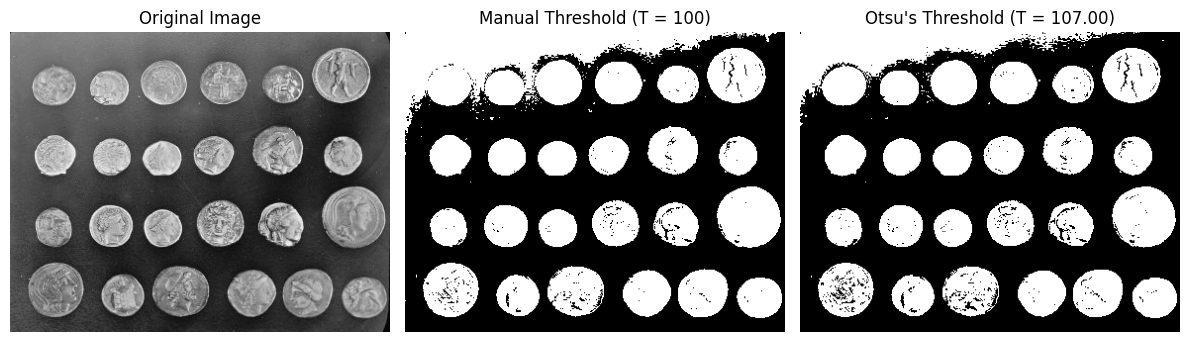

Nilai threshold Otsu yang ditemukan: 107


In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.color import rgb2gray

# =========================================
# 1. Memuat citra (contoh: coins)
# =========================================
image_coins = data.coins()  # Citra sudah dalam bentuk grayscale

# =========================================
# 2. Thresholding Global (manual)
# =========================================
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# =========================================
# 3. Thresholding Otsu
# =========================================
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# =========================================
# 4. Visualisasi hasil
# =========================================
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli
ax[0].imshow(image_coins, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

# Hasil threshold manual
ax[1].imshow(binary_manual, cmap='gray')
ax[1].set_title(f'Manual Threshold (T = {thresh_manual})')
ax[1].axis('off')

# Hasil threshold Otsu
ax[2].imshow(binary_otsu, cmap='gray')
ax[2].set_title(f"Otsu's Threshold (T = {thresh_otsu:.2f})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

# =========================================
# 5. Menampilkan nilai threshold Otsu
# =========================================
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

### Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)

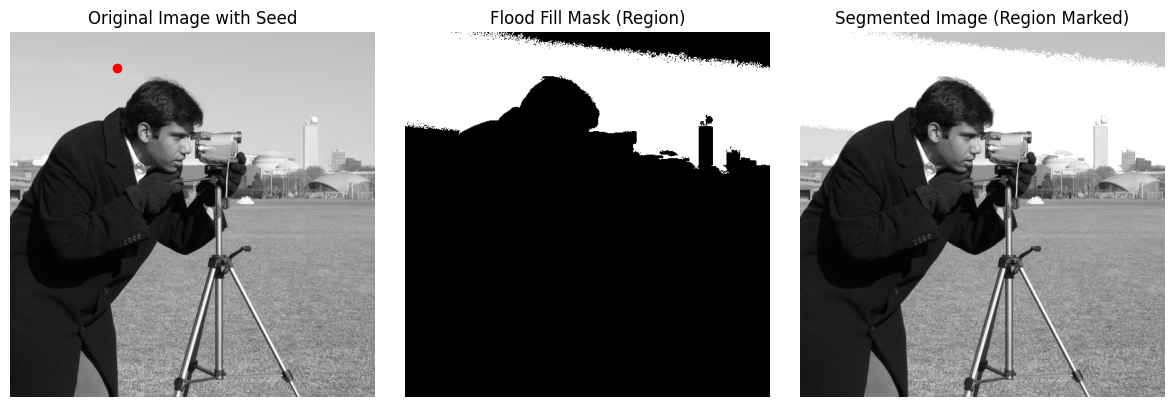

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation

# =========================================
# 1. Memuat citra (contoh: camera)
# =========================================
image_camera = data.camera()  # Citra grayscale

# =========================================
# 2. Menentukan titik seed (benih)
# =========================================
# Contoh: titik di area tertentu (y, x)
seed_point = (50, 150)

# =========================================
# 3. Region Growing (menggunakan flood fill)
# =========================================
# tolerance = batas perbedaan intensitas
flood_mask = segmentation.flood(
    image_camera,
    seed_point,
    tolerance=10
)

# =========================================
# 4. Membuat citra hasil segmentasi
# =========================================
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # Tandai region dengan warna putih

# =========================================
# 5. Visualisasi hasil
# =========================================
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli + seed point
ax[0].imshow(image_camera, cmap='gray')
ax[0].plot(seed_point[1], seed_point[0], 'ro')  # Titik seed (x, y)
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

# Mask hasil region growing
ax[1].imshow(flood_mask, cmap='gray')
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

# Hasil segmentasi
ax[2].imshow(segmented_image, cmap='gray')
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering

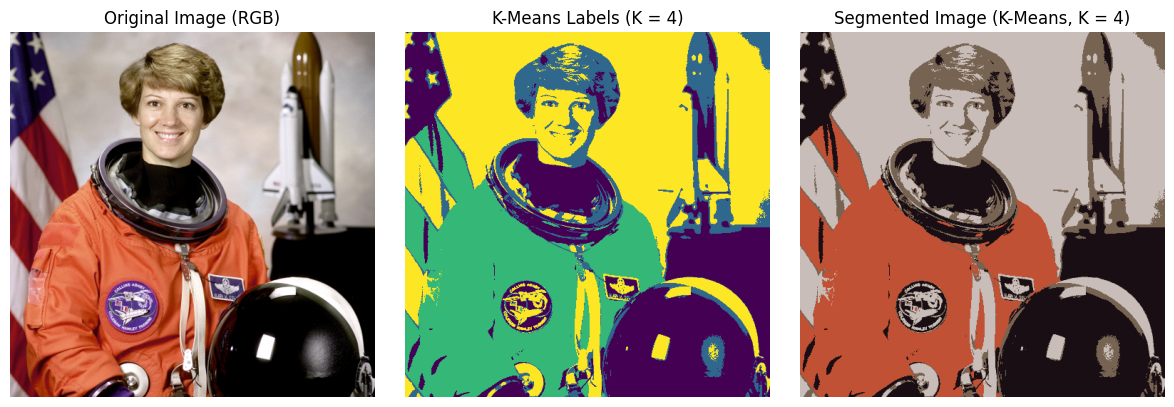

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# =========================================
# 1. Memuat citra berwarna (astronaut)
# =========================================
image_astro = data.astronaut()

# Konversi ke float (0–1)
image_astro_float = image_astro.astype(float) / 255.0

# =========================================
# 2. Konversi ke ruang warna Lab
# =========================================
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape

# Ubah menjadi array 2D: [jumlah_piksel, fitur]
pixel_features = image_lab.reshape(rows * cols, dims)

# =========================================
# 3. K-Means Clustering
# =========================================
n_clusters = 4

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=0,
    n_init=10  # gunakan 'auto' jika sklearn versi baru
)

# Menghindari warning
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# =========================================
# 4. Reshape label ke bentuk citra
# =========================================
segmented_labels = pixel_labels.reshape(rows, cols)

# =========================================
# 5. Membuat citra hasil segmentasi
# =========================================
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):
    # Mask untuk klaster ke-k
    mask_k = (pixel_labels == k).reshape(rows, cols)

    # Isi dengan warna pusat klaster
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# =========================================
# 6. Visualisasi hasil
# =========================================
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli
ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# Label klaster
ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K = {n_clusters})')
ax[1].axis('off')

# Hasil segmentasi
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K = {n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed

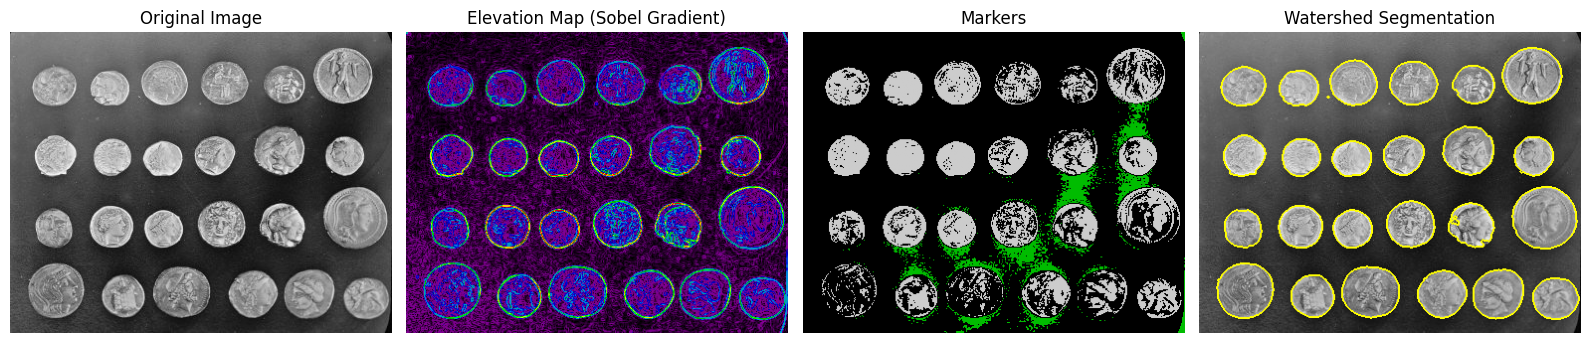

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation
from scipy import ndimage as ndi

# =========================================
# 1. Memuat citra (contoh: coins)
# =========================================
image_coins = data.coins()

# =========================================
# 2. Menghitung gradien (elevation map)
# =========================================
# Gradien digunakan sebagai "topografi"
elevation_map = filters.sobel(image_coins)

# =========================================
# 3. Menentukan marker
# =========================================
# Marker sederhana berdasarkan threshold
markers = np.zeros_like(image_coins)

# Background
markers[image_coins < 30] = 1

# Objek (koin)
markers[image_coins > 150] = 2

# (Opsional) Marker lebih kompleks menggunakan local maxima
# from skimage.feature import peak_local_max
# coordinates = peak_local_max(image_coins, min_distance=20)
# markers = np.zeros(image_coins.shape, dtype=bool)
# markers[tuple(coordinates.T)] = True
# markers = ndi.label(markers)[0]

# =========================================
# 4. Watershed segmentation
# =========================================
segmentation_watershed = segmentation.watershed(
    elevation_map,
    markers
)

# Tandai batas segmentasi
segmented_colored = segmentation.mark_boundaries(
    image_coins,
    segmentation_watershed
)

# =========================================
# 5. Visualisasi hasil
# =========================================
fig, axes = plt.subplots(
    ncols=4,
    figsize=(16, 4),
    sharex=True,
    sharey=True
)
ax = axes.ravel()

# Gambar asli
ax[0].imshow(image_coins, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

# Elevation map
ax[1].imshow(elevation_map, cmap='nipy_spectral')
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

# Marker
ax[2].imshow(markers, cmap='nipy_spectral')
ax[2].set_title('Markers')
ax[2].axis('off')

# Hasil watershed
ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

### Praktikum 5. Perbandingan Visual Hasil Segmentasi

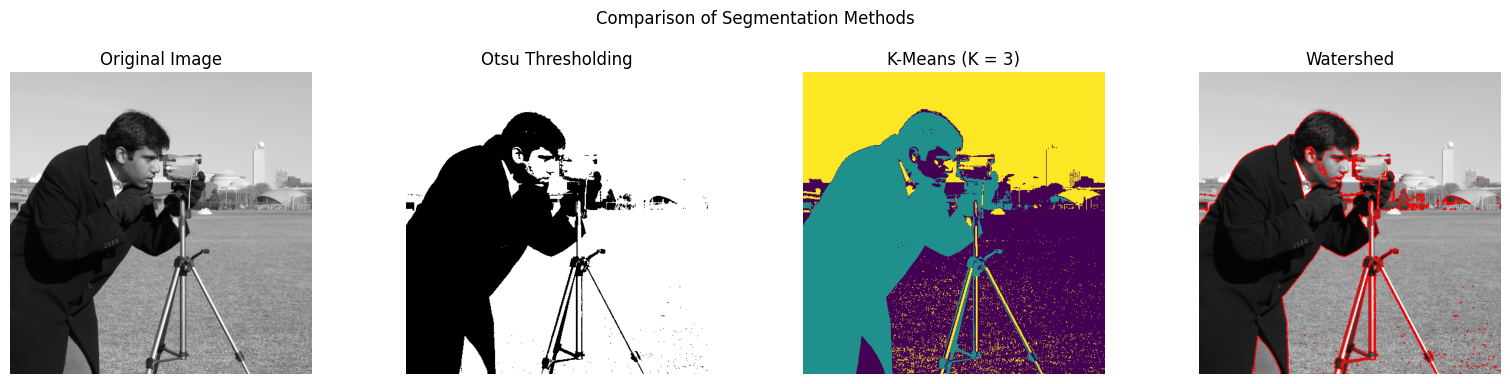

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float
from sklearn.cluster import KMeans
import warnings

# =========================================
# 1. Memuat citra (camera)
# =========================================
image = data.camera()
image_float = img_as_float(image)

# =========================================
# 2. Segmentasi dengan beberapa metode
# =========================================

# -----------------------------------------
# a) Otsu Thresholding
# -----------------------------------------
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# -----------------------------------------
# b) K-Means Clustering (K = 3)
# -----------------------------------------
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)

n_clusters = 3
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=0,
    n_init=10
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# -----------------------------------------
# c) Watershed
# -----------------------------------------
elevation_map = filters.sobel(image)

markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2

segmentation_watershed = segmentation.watershed(
    elevation_map,
    markers
)

# Tandai batas segmentasi
segmented_watershed_colored = segmentation.mark_boundaries(
    image_float,
    segmentation_watershed,
    color=(1, 0, 0)  # warna merah
)

# =========================================
# 3. Visualisasi perbandingan
# =========================================
fig, axes = plt.subplots(
    1, 4,
    figsize=(16, 4),
    sharex=True,
    sharey=True
)
ax = axes.ravel()

# Original
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

# Otsu
ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

# K-Means
ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K = {n_clusters})')
ax[2].axis('off')

# Watershed
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Penugasan

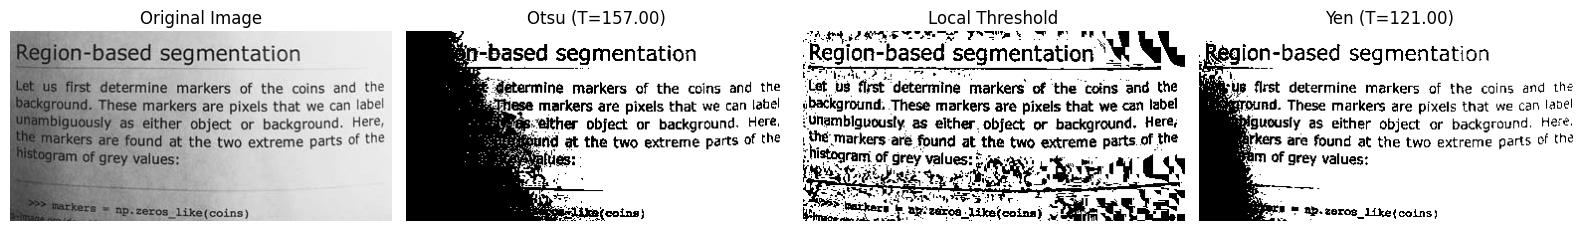

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters

# =========================================
# 1. Memuat citra
# =========================================
image = data.page()  # Citra dokumen (teks)

# =========================================
# 2. Otsu Thresholding
# =========================================
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# =========================================
# 3. Threshold Local (Adaptive)
# =========================================
block_size = 35  # ukuran area lokal
thresh_local = filters.threshold_local(image, block_size)
binary_local = image > thresh_local

# =========================================
# 4. Threshold Yen
# =========================================
thresh_yen = filters.threshold_yen(image)
binary_yen = image > thresh_yen

# =========================================
# 5. Visualisasi
# =========================================
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title(f'Otsu (T={thresh_otsu:.2f})')
ax[1].axis('off')

ax[2].imshow(binary_local, cmap='gray')
ax[2].set_title('Local Threshold')
ax[2].axis('off')

ax[3].imshow(binary_yen, cmap='gray')
ax[3].set_title(f'Yen (T={thresh_yen:.2f})')
ax[3].axis('off')

plt.tight_layout()
plt.show()

Saving buah.jpg to buah.jpg


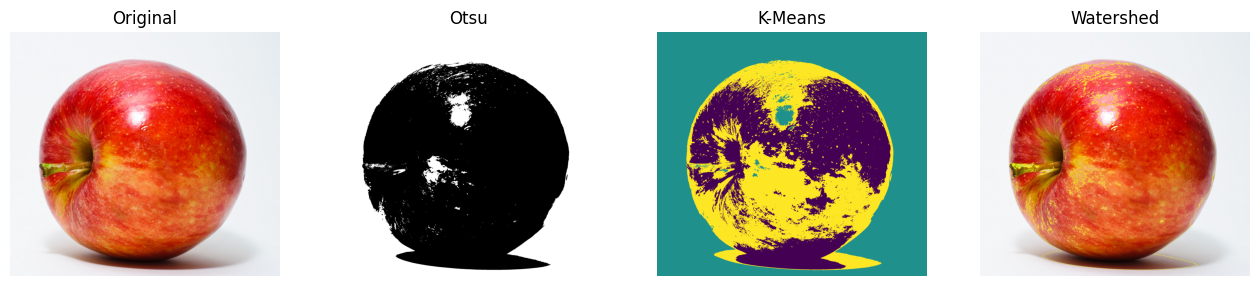

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, segmentation, color, img_as_float
from sklearn.cluster import KMeans
from google.colab import files

# Upload file dari local
uploaded = files.upload()

# =========================================
# 1. Load image
# =========================================
image = io.imread('buah.jpg')
image_gray = color.rgb2gray(image)
image_float = img_as_float(image_gray)

# =========================================
# 2. OTSU
# =========================================
thresh_otsu = filters.threshold_otsu(image_gray)
binary_otsu = image_gray > thresh_otsu

# =========================================
# 3. K-MEANS
# =========================================
rows, cols = image_gray.shape
pixel_features = image_float.reshape(rows * cols, 1)

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
labels = kmeans.fit_predict(pixel_features)
segmented_kmeans = labels.reshape(rows, cols)

# =========================================
# 4. WATERSHED (FIX DI SINI)
# =========================================
elevation_map = filters.sobel(image_gray)

# HARUS integer
markers = np.zeros_like(image_gray, dtype=np.int32)
markers[image_gray < thresh_otsu] = 1
markers[image_gray > thresh_otsu] = 2

segmented_watershed = segmentation.watershed(elevation_map, markers)

# boundary visualization
watershed_result = segmentation.mark_boundaries(image, segmented_watershed)

# =========================================
# 5. VISUALISASI
# =========================================
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].imshow(image)
ax[0].set_title("Original")

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title("Otsu")

ax[2].imshow(segmented_kmeans, cmap='viridis')
ax[2].set_title("K-Means")

ax[3].imshow(watershed_result)
ax[3].set_title("Watershed")

for a in ax:
    a.axis('off')

plt.show()